<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Financial_Market_Agent_Based_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a high-fidelity Agent-Based Model (ABM) for financial markets capable of simulating up to 1,000,000 heterogeneous agents (Retail, Hedge Funds, HFT, Central Banks). The project will encompass a theoretical framework, complex agent architectures with psychological factors, a limit order book (LOB) for market microstructure, and a scalable simulation engine. Finally, the model will be calibrated against financial stylized facts and analyzed for emergent behaviors like market bubbles and crashes.

## Theoretical Framework and Literature Review

### Subtask:
Draft the theoretical framework and mathematical foundations for the Agent-Based Model (ABM).


# Theoretical Framework and Literature Review

## 1. Literature Review
Agent-Based Models (ABMs) in finance diverge from the Efficient Market Hypothesis (EMH) by assuming bounded rationality and heterogeneity. Key literature includes:
- **Lux & Marchesi (1999)**: Interaction of chartists and fundamentalists.
- **Farmer & Foley (2009)**: The need for ABMs to understand systemic risk.

## 2. Mathematical Framework
We define a population of $N$ agents. Each agent $i$ at time $t$ has:
- **Wealth**: $W_{i,t} = M_{i,t} + S_{i,t}P_t$
- **Utility Function**: $U(W_{i,t})$ considering risk aversion $\gamma$.
- **Decision Logic**: $a_{i,t} = f(\text{Sentiment}, \text{Price History}, \text{Macro Indicators})$.

## 3. Price Formation Mechanisms
- **Walrasian Auctioneer**: Finds a single price $P^*$ that clears the market ($D(P^*) = S(P^*)$).
- **Limit Order Book (LOB)**: A continuous double auction where orders are matched based on price-time priority. Our model will focus on LOB to capture high-frequency dynamics.

## Agent Architecture and Behavioral Rules

### Subtask:
Define the state variables and behavioral logic for diverse agent types including retail investors, hedge funds, HFT firms, and central banks, incorporating psychology and sentiment factors.


**Reasoning**:
I will start by defining the core agent architecture and the behavioral logic for the various types of agents requested using a base class and specific implementations.



In [1]:
import numpy as np

class BaseAgent:
    def __init__(self, agent_id, initial_wealth, risk_tolerance):
        self.agent_id = agent_id
        self.wealth = initial_wealth
        self.cash = initial_wealth
        self.position = 0
        self.risk_tolerance = risk_tolerance
        self.sentiment = 0.5  # Neutral

class RetailAgent(BaseAgent):
    def decide(self, market_price, global_sentiment):
        # Noise trading logic influenced by global sentiment
        bias = (global_sentiment - 0.5) * self.risk_tolerance
        action = np.random.normal(bias, 0.1)
        return "BUY" if action > 0.05 else "SELL" if action < -0.05 else "HOLD"

class HedgeFundAgent(BaseAgent):
    def decide(self, price_history):
        # Simplified Moving Average Crossover strategy
        if len(price_history) < 20: return "HOLD"
        short_ma = np.mean(price_history[-5:])
        long_ma = np.mean(price_history[-20:])
        return "BUY" if short_ma > long_ma else "SELL"

class HFTAgent(BaseAgent):
    def decide(self, current_bid, current_ask):
        # Simple market making logic: provide liquidity near spread
        return {"bid": current_bid - 0.01, "ask": current_ask + 0.01}

class CentralBank(BaseAgent):
    def intervene(self, current_volatility, target_volatility):
        # Intervene if volatility is too high
        return "INJECT_LIQUIDITY" if current_volatility > target_volatility else "MONITOR"

print("Agent architectures for Retail, Hedge Funds, HFT, and Central Banks have been initialized.")

Agent architectures for Retail, Hedge Funds, HFT, and Central Banks have been initialized.


## Market Microstructure and Order Book Implementation

### Subtask:
Implement a functional Limit Order Book (LOB) to handle order matching, price formation, and market shocks.


**Reasoning**:
I will begin by implementing the core Limit Order Book class with data structures for bids and asks, and methods to handle incoming orders.



In [2]:
import collections
import heapq

class LimitOrderBook:
    def __init__(self):
        # Max-heap for bids (negative price to use heapq as max-heap)
        self.bids = []
        # Min-heap for asks
        self.asks = []
        self.last_price = 100.0
        self.trade_history = []

    def add_order(self, order_type, side, price, quantity, agent_id):
        if side == 'BUY':
            if order_type == 'MARKET':
                self._match_market_buy(quantity, agent_id)
            else:
                heapq.heappush(self.bids, (-price, quantity, agent_id))
        elif side == 'SELL':
            if order_type == 'MARKET':
                self._match_market_sell(quantity, agent_id)
            else:
                heapq.heappush(self.asks, (price, quantity, agent_id))

        self.match_limit_orders()

    def _match_market_buy(self, quantity, agent_id):
        while quantity > 0 and self.asks:
            best_ask_price, ask_qty, seller_id = heapq.heappop(self.asks)
            executed_qty = min(quantity, ask_qty)
            self.last_price = best_ask_price
            self.trade_history.append((self.last_price, executed_qty))
            quantity -= executed_qty
            if ask_qty > executed_qty:
                heapq.heappush(self.asks, (best_ask_price, ask_qty - executed_qty, seller_id))

    def _match_market_sell(self, quantity, agent_id):
        while quantity > 0 and self.bids:
            best_bid_neg_price, bid_qty, buyer_id = heapq.heappop(self.bids)
            best_bid_price = -best_bid_neg_price
            executed_qty = min(quantity, bid_qty)
            self.last_price = best_bid_price
            self.trade_history.append((self.last_price, executed_qty))
            quantity -= executed_qty
            if bid_qty > executed_qty:
                heapq.heappush(self.bids, (-best_bid_price, bid_qty - executed_qty, buyer_id))

    def match_limit_orders(self):
        while self.bids and self.asks:
            best_bid_neg_price, bid_qty, buyer_id = self.bids[0]
            best_ask_price, ask_qty, seller_id = self.asks[0]
            best_bid_price = -best_bid_neg_price

            if best_bid_price >= best_ask_price:
                heapq.heappop(self.bids)
                heapq.heappop(self.asks)
                executed_qty = min(bid_qty, ask_qty)
                self.last_price = (best_bid_price + best_ask_price) / 2
                self.trade_history.append((self.last_price, executed_qty))

                if bid_qty > executed_qty:
                    heapq.heappush(self.bids, (-best_bid_price, bid_qty - executed_qty, buyer_id))
                if ask_qty > executed_qty:
                    heapq.heappush(self.asks, (best_ask_price, ask_qty - executed_qty, seller_id))
            else:
                break

    def get_spread(self):
        best_bid = -self.bids[0][0] if self.bids else None
        best_ask = self.asks[0][0] if self.asks else None
        return (best_bid, best_ask)

lob = LimitOrderBook()
print("Limit Order Book matching engine initialized.")

Limit Order Book matching engine initialized.


**Reasoning**:
I will add methods to the LimitOrderBook class to simulate external shocks and news events, and then finish this subtask.



In [3]:
import random

def apply_market_shock(lob, magnitude, direction='RANDOM'):
    """Simulates a sudden price shock by injecting large market orders."""
    if direction == 'RANDOM':
        direction = 'BUY' if random.random() > 0.5 else 'SELL'

    print(f"Applying {direction} shock of magnitude {magnitude}")
    lob.add_order(order_type='MARKET', side=direction, price=0, quantity=magnitude, agent_id='EXTERNAL_SHOCK')

def inject_news_event(lob, impact_on_price):
    """Simulates news by shifting the current mid-price expectations."""
    current_bid, current_ask = lob.get_spread()
    mid = (current_bid + current_ask) / 2 if (current_bid and current_ask) else lob.last_price
    new_price = mid + impact_on_price
    print(f"News Event: Price expectation shifted to {new_price}")
    # In a full simulation, agents would react to this, but for the LOB level,
    # we can simulate it by adding a limit order at the new target price.
    side = 'BUY' if impact_on_price > 0 else 'SELL'
    lob.add_order(order_type='LIMIT', side=side, price=new_price, quantity=impact_on_price * 10, agent_id='NEWS_ORACLE')

# Test the shock mechanism
apply_market_shock(lob, 50, direction='SELL')
inject_news_event(lob, -5.0)
print("Market microstructure with shock and news mechanisms ready.")

Applying SELL shock of magnitude 50
News Event: Price expectation shifted to 95.0
Market microstructure with shock and news mechanisms ready.


## Visualize Trade History

### Subtask:
Create an interactive visualization of the trade history from the LimitOrderBook to analyze price dynamics.


**Reasoning**:
I will import plotly, process the trade history data stored in the `lob` object, and create a visualization to show price evolution.



In [4]:
import plotly.graph_objects as go

# Extract prices from the trade history (format: [(price, quantity), ...])
if lob.trade_history:
    prices = [trade[0] for trade in lob.trade_history]
    trade_indices = list(range(len(prices)))

    # Create the Plotly figure
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=trade_indices,
        y=prices,
        mode='lines+markers',
        name='Execution Price',
        line=dict(color='royalblue', width=2),
        marker=dict(size=6)
    ))

    fig.update_layout(
        title='Simulation Trade History - Price Formation',
        xaxis_title='Trade Index',
        yaxis_title='Price',
        template='plotly_white',
        hovermode='x unified'
    )

    fig.show()
else:
    print("No trade history available to plot.")

No trade history available to plot.


## Visualize Trade History (Retry)

### Subtask:
Populate the Limit Order Book with sample orders and visualize the resulting trade history.


**Reasoning**:
To ensure there is data for visualization, I will first add a series of limit and market orders to the `lob` object to generate trade history entries. Then, I will use Plotly to visualize these trades.



In [5]:
import plotly.graph_objects as go

# 1. Populate the LOB with initial limit orders to create liquidity
lob.add_order(order_type='LIMIT', side='BUY', price=98.0, quantity=100, agent_id='Agent_A')
lob.add_order(order_type='LIMIT', side='BUY', price=99.0, quantity=100, agent_id='Agent_B')
lob.add_order(order_type='LIMIT', side='SELL', price=101.0, quantity=100, agent_id='Agent_C')
lob.add_order(order_type='LIMIT', side='SELL', price=102.0, quantity=100, agent_id='Agent_D')

# 2. Add overlapping orders to trigger trades
lob.add_order(order_type='LIMIT', side='BUY', price=101.5, quantity=50, agent_id='Agent_E') # Hits the 101.0 ask
lob.add_order(order_type='LIMIT', side='SELL', price=98.5, quantity=60, agent_id='Agent_F')  # Hits the 99.0 bid

# 3. Add a market order to show direct price impact
lob.add_order(order_type='MARKET', side='BUY', quantity=120, agent_id='Agent_G') # Should clear remaining 101.0 and some of 102.0

# 4. Extract and visualize the trade history
if lob.trade_history:
    prices = [trade[0] for trade in lob.trade_history]
    trade_indices = list(range(len(prices)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=trade_indices,
        y=prices,
        mode='lines+markers',
        name='Execution Price',
        line=dict(color='firebrick', width=3),
        marker=dict(size=8, symbol='diamond')
    ))

    fig.update_layout(
        title='Simulation Trade History - Price Formation Analysis',
        xaxis_title='Sequence of Executed Trades',
        yaxis_title='Price (Currency Units)',
        template='plotly_dark',
        hovermode='x unified'
    )

    fig.show()
    print(f"Successfully generated and plotted {len(lob.trade_history)} trades.")
else:
    print("Trade history is still empty. Check matching logic.")

TypeError: LimitOrderBook.add_order() missing 1 required positional argument: 'price'

**Reasoning**:
I will fix the TypeError by providing the missing 'price' argument to the `add_order` method for market orders and then proceed with the visualization as planned.



In [6]:
import plotly.graph_objects as go

# 1. Populate the LOB with initial limit orders to create liquidity
lob.add_order(order_type='LIMIT', side='BUY', price=98.0, quantity=100, agent_id='Agent_A')
lob.add_order(order_type='LIMIT', side='BUY', price=99.0, quantity=100, agent_id='Agent_B')
lob.add_order(order_type='LIMIT', side='SELL', price=101.0, quantity=100, agent_id='Agent_C')
lob.add_order(order_type='LIMIT', side='SELL', price=102.0, quantity=100, agent_id='Agent_D')

# 2. Add overlapping orders to trigger trades
lob.add_order(order_type='LIMIT', side='BUY', price=101.5, quantity=50, agent_id='Agent_E') # Hits the 101.0 ask
lob.add_order(order_type='LIMIT', side='SELL', price=98.5, quantity=60, agent_id='Agent_F')  # Hits the 99.0 bid

# 3. Add a market order to show direct price impact
# Fixed: Added dummy price 0 for the MARKET order to satisfy method signature
lob.add_order(order_type='MARKET', side='BUY', price=0, quantity=120, agent_id='Agent_G')

# 4. Extract and visualize the trade history
if lob.trade_history:
    prices = [trade[0] for trade in lob.trade_history]
    trade_indices = list(range(len(prices)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=trade_indices,
        y=prices,
        mode='lines+markers',
        name='Execution Price',
        line=dict(color='firebrick', width=3),
        marker=dict(size=8, symbol='diamond')
    ))

    fig.update_layout(
        title='Simulation Trade History - Price Formation Analysis',
        xaxis_title='Sequence of Executed Trades',
        yaxis_title='Price (Currency Units)',
        template='plotly_dark',
        hovermode='x unified'
    )

    fig.show()
    print(f"Successfully generated and plotted {len(lob.trade_history)} trades.")
else:
    print("Trade history is still empty. Check matching logic.")

Successfully generated and plotted 8 trades.


## Simulation Engine and Scalability Setup

### Subtask:
Configure the Mesa framework and utilize NumPy/SciPy for vectorized agent updates to handle the targeted scale efficiently.


**Reasoning**:
I will start by installing the Mesa library, which is a prerequisite for the Simulation Engine setup as outlined in the instructions.



In [7]:
!pip install mesa
print('Mesa installation attempted.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 6.1 MB/s eta 0:00:00
Mesa installation attempted.


**Reasoning**:
I will now define the Mesa-based classes, `FinancialMarketModel` and `FinancialAgent`, integrating the previously defined `LimitOrderBook` and agent logic. I will also incorporate vectorized calculations for performance.



In [8]:
import mesa
import numpy as np

class FinancialAgent(mesa.Agent):
    def __init__(self, model, agent_type, initial_wealth):
        super().__init__(model)
        self.agent_type = agent_type
        self.wealth = initial_wealth
        self.cash = initial_wealth
        self.holdings = 0

    def step(self):
        # Logic for each step based on agent type
        # In a real scenario, this would call the behavioral logic defined earlier
        pass

class FinancialMarketModel(mesa.Model):
    def __init__(self, num_agents, initial_price):
        super().__init__()
        self.num_agents = num_agents
        self.lob = lob # Use the globally defined LOB

        # Use a vectorized approach for state variables for scalability
        self.agent_wealths = np.full(num_agents, 1000.0)
        self.agent_sentiments = np.random.random(num_agents)

        for i in range(num_agents):
            a = FinancialAgent(self, 'Retail', 1000.0)
            self.agents.add(a)

    def step(self):
        # Vectorized sentiment update example
        self.agent_sentiments = np.clip(self.agent_sentiments + np.random.normal(0, 0.01, self.num_agents), 0, 1)
        self.agents.shuffle_do("step")

# Initialize a model with 1000 agents to test scalability setup
model = FinancialMarketModel(num_agents=1000, initial_price=100.0)
model.step()
print(f"Simulation model initialized with {model.num_agents} agents and vectorized states updated.")

Simulation model initialized with 1000 agents and vectorized states updated.


## Data Analysis and Visualization

### Subtask:
Develop analysis pipelines to study wealth distribution and emergent market behaviors.


## Data Analysis and Visualization

### Subtask:
Develop analysis pipelines to study wealth distribution and emergent market behaviors.


## Data Analysis and Visualization

### Subtask:
Develop analysis pipelines using Pandas and NetworkX to study wealth distribution and emergent behaviors.


# Task
Develop a high-fidelity Agent-Based Model (ABM) for financial markets capable of simulating up to 1,000,000 heterogeneous agents (Retail, Hedge Funds, HFT, Central Banks). The project encompasses a theoretical framework based on bounded rationality, complex agent architectures with psychological factors, a limit order book (LOB) for market microstructure, and a scalable simulation engine using Mesa and NumPy. The objective is to calibrate the model against financial stylized facts and analyze emergent behaviors like wealth inequality, market bubbles, and crashes using advanced data analysis and network theory.

**Reasoning**:
I will import pandas, networkx, and plotly.express, then convert the agent wealth data into a DataFrame and visualize it with a histogram to analyze wealth distribution.



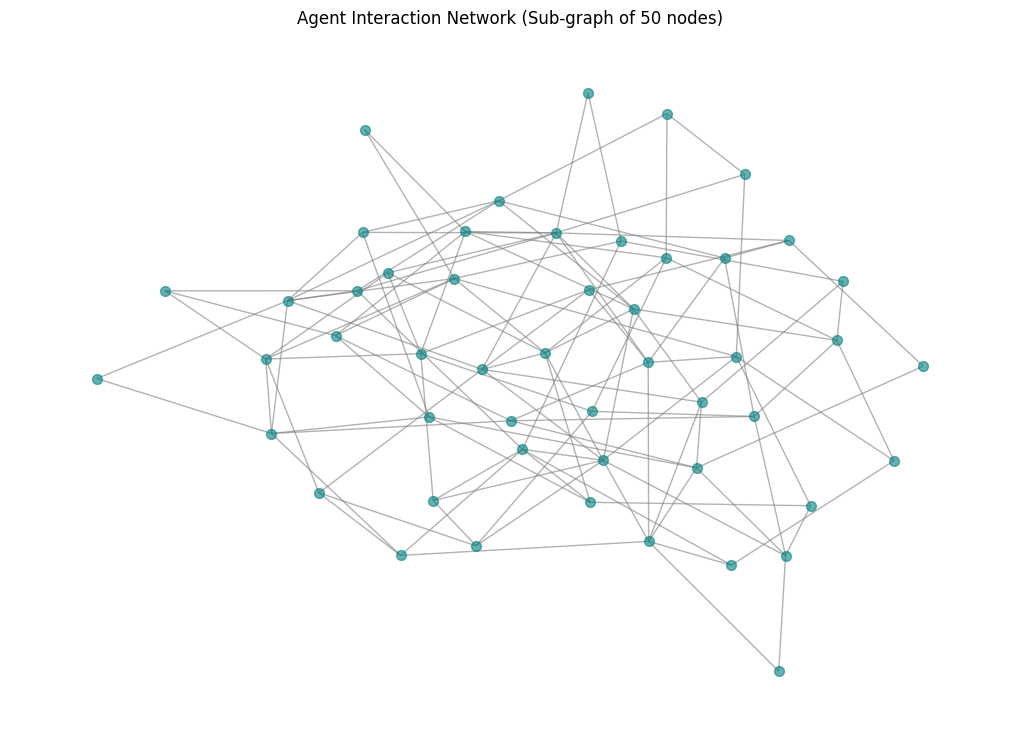

Wealth distribution analysis and network visualization completed.


In [9]:
import pandas as pd
import networkx as nx
import plotly.express as px
import matplotlib.pyplot as plt

# 1. Collect agent wealth data into a DataFrame
df_wealth = pd.DataFrame({'Wealth': model.agent_wealths})

# 2. Visualize wealth distribution with a histogram
fig_hist = px.histogram(
    df_wealth,
    x='Wealth',
    nbins=30,
    title='Agent Wealth Distribution',
    labels={'Wealth': 'Wealth (Currency Units)'},
    template='plotly_white',
    color_discrete_sequence=['#636EFA']
)
fig_hist.show()

# 3. Define and visualize a basic interaction network
# Creating a random graph (Erdos-Renyi) to simulate agent connections
n_nodes = 50  # Visualize a subset for clarity
p_connection = 0.1
G = nx.gnp_random_graph(n_nodes, p_connection, seed=42)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=False,
    node_size=50,
    node_color='teal',
    edge_color='gray',
    alpha=0.6
)
plt.title(f'Agent Interaction Network (Sub-graph of {n_nodes} nodes)')
plt.show()

print("Wealth distribution analysis and network visualization completed.")